# Exploratory Data Analysis - Credit Card Fraud Detection

This notebook explores the `fraudTrain.csv` dataset to understand its structure, distributions, and patterns before cleaning and model training.

**Dataset**: Synthetic credit card transaction data with 1,296,675 transactions and 23 features.
**Target**: `is_fraud` (1 = fraud, 0 = legitimate)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

## 1. Data Overview

In [2]:
# Load the dataset
df = pd.read_csv('dataset/fraudTrain.csv')
print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
print('\n--- Data Types ---')
print(df.dtypes)

Dataset shape: 1296675 rows, 23 columns

--- Data Types ---
Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


In [3]:
# First 5 rows
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found!')

# Check for duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
No missing values found!



Duplicate rows: 0


## 2. Class Distribution (Target Variable)

Class distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud percentage: 0.5789%


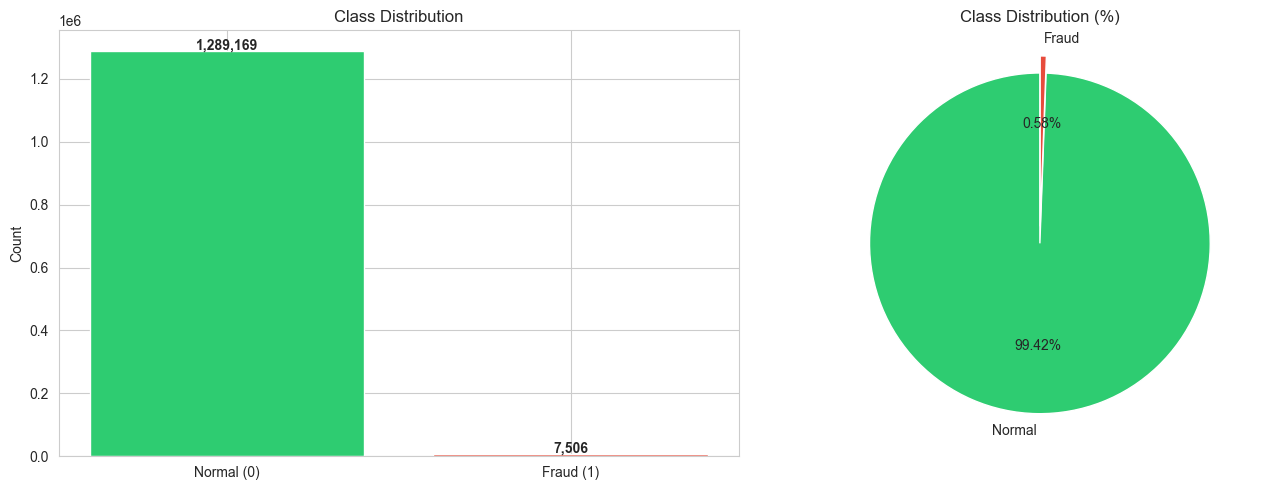

In [5]:
# Class distribution
class_counts = df['is_fraud'].value_counts()
print('Class distribution:')
print(class_counts)
print(f'\nFraud percentage: {class_counts[1] / len(df) * 100:.4f}%')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Normal (0)', 'Fraud (1)'], class_counts.values, color=colors)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Normal', 'Fraud'], autopct='%1.2f%%',
            colors=colors, startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

## 3. Transaction Amount Analysis

Amount statistics by class:


              count    mean     std   min     25%     50%     75%       max
is_fraud                                                                   
0         1289169.0   67.67  154.01  1.00    9.61   47.28   82.54  28948.90
1            7506.0  531.32  390.56  1.06  245.66  396.50  900.88   1376.04


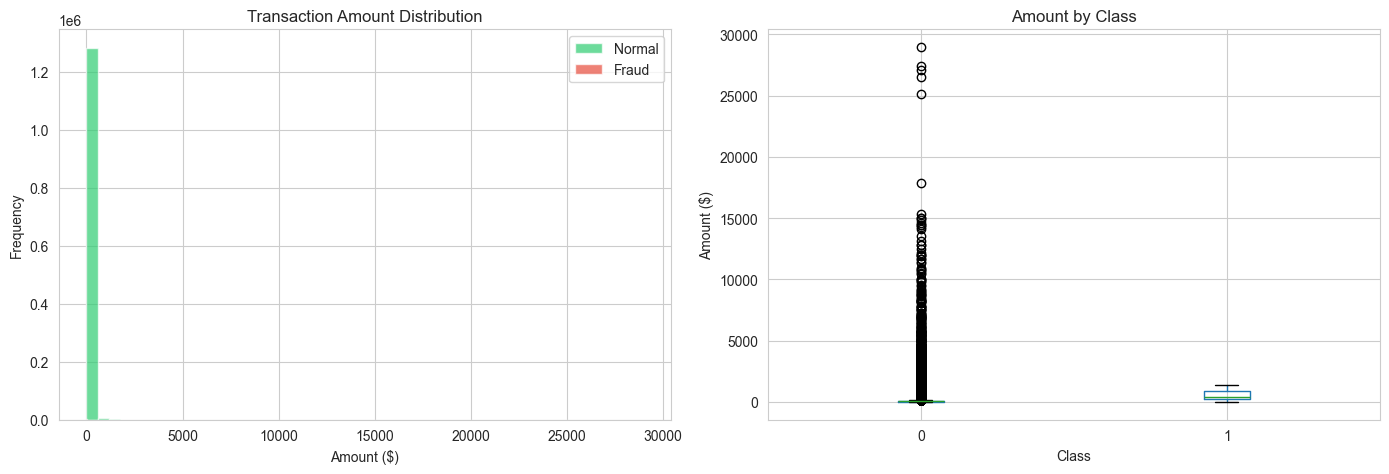

In [6]:
# Amount statistics by class
print('Amount statistics by class:')
print(df.groupby('is_fraud')['amt'].describe().round(2))

# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[df['is_fraud'] == 0]['amt'], bins=50, alpha=0.7, label='Normal', color='#2ecc71')
axes[0].hist(df[df['is_fraud'] == 1]['amt'], bins=50, alpha=0.7, label='Fraud', color='#e74c3c')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot
df.boxplot(column='amt', by='is_fraud', ax=axes[1])
axes[1].set_title('Amount by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Amount ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

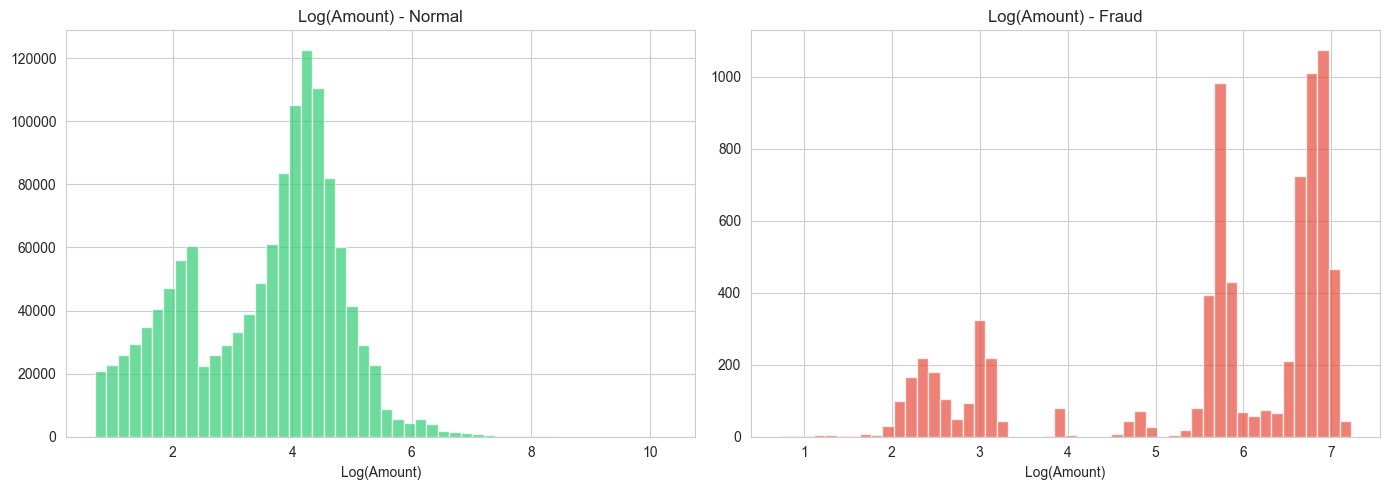

In [7]:
# Log-scale amount distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, cls in enumerate([0, 1]):
    data = df[df['is_fraud'] == cls]['amt']
    axes[i].hist(np.log1p(data), bins=50, alpha=0.7, color=colors[i])
    axes[i].set_title(f'Log(Amount) - {"Normal" if cls == 0 else "Fraud"}')
    axes[i].set_xlabel('Log(Amount)')

plt.tight_layout()
plt.show()

## 4. Temporal Analysis

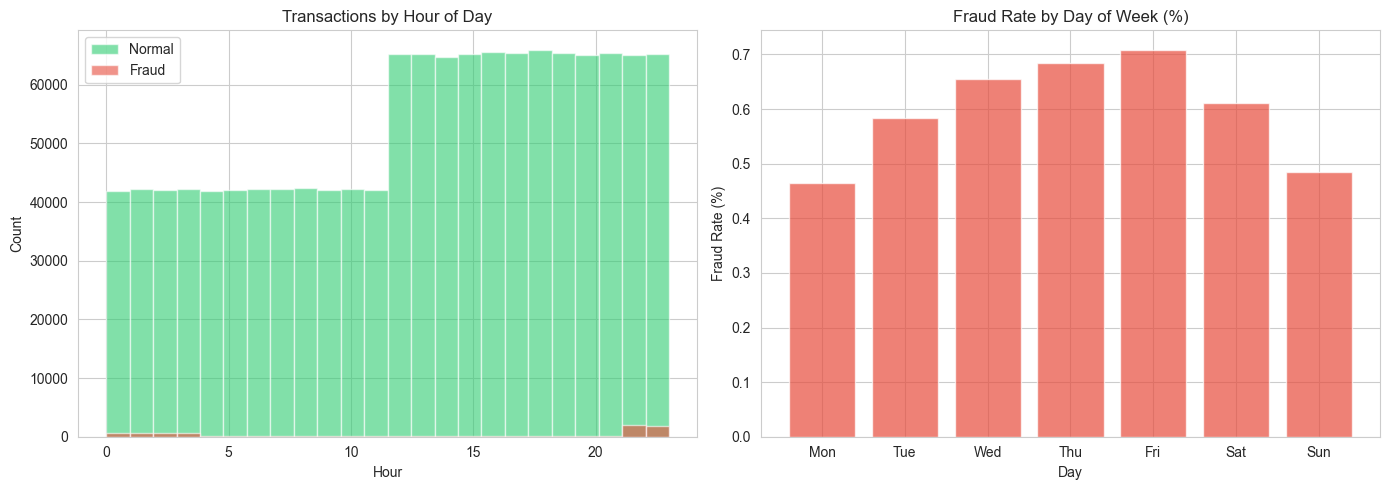

In [8]:
# Parse datetime
df['trans_date'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date'].dt.hour
df['day_of_week'] = df['trans_date'].dt.dayofweek
df['month'] = df['trans_date'].dt.month

# Transactions by hour
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hour distribution
for cls, color, label in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Fraud')]:
    data = df[df['is_fraud'] == cls]['hour']
    axes[0].hist(data, bins=24, alpha=0.6, label=label, color=color)
axes[0].set_title('Transactions by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')
axes[0].legend()

# Day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fraud_rate_by_day = df.groupby('day_of_week')['is_fraud'].mean() * 100
axes[1].bar(day_names, fraud_rate_by_day.values, color='#e74c3c', alpha=0.7)
axes[1].set_title('Fraud Rate by Day of Week (%)')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

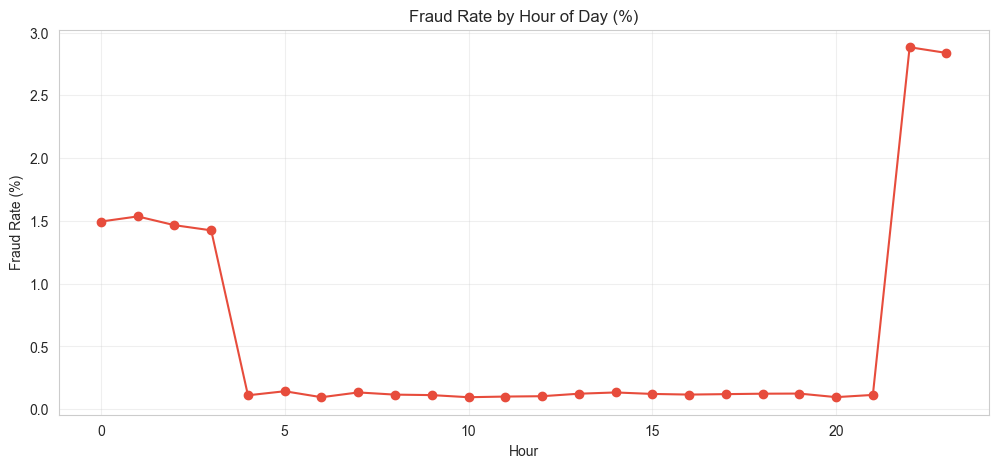

In [9]:
# Fraud rate by hour
fraud_rate_by_hour = df.groupby('hour')['is_fraud'].mean() * 100
plt.figure(figsize=(12, 5))
plt.plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values, marker='o', color='#e74c3c')
plt.title('Fraud Rate by Hour of Day (%)')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate (%)')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Customer Age Analysis

Age statistics by class:
              count  mean   std   min   25%   50%   75%   max
is_fraud                                                     
0         1289169.0  46.0  17.4  13.9  32.6  44.0  57.0  95.6
1            7506.0  48.8  18.9  14.4  33.0  47.8  61.0  93.8


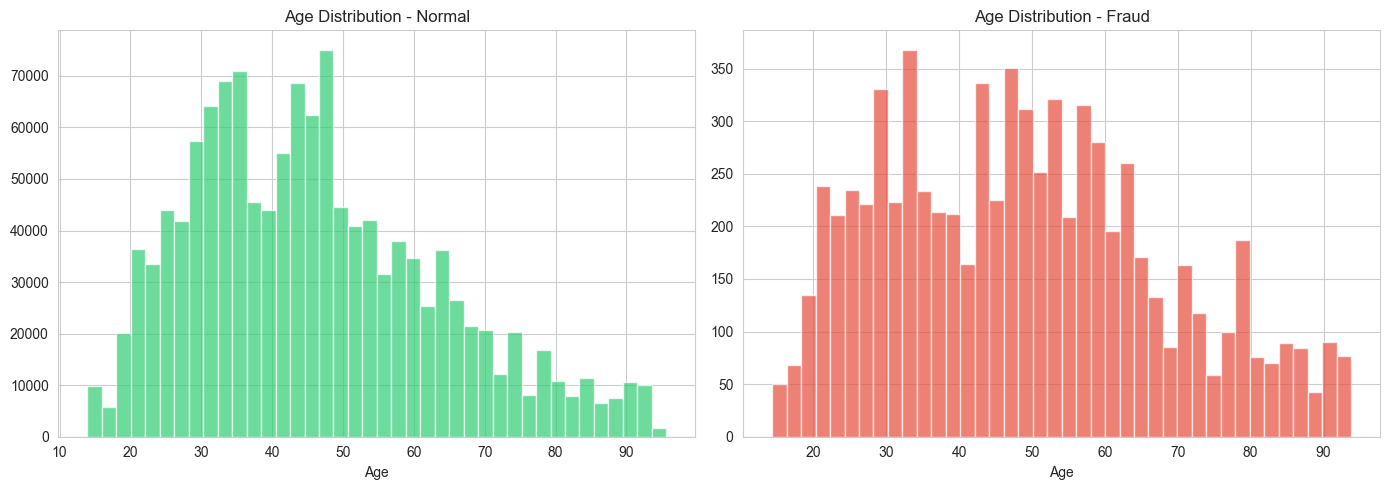

In [10]:
# Compute age from DOB
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (df['trans_date'] - df['dob']).dt.days / 365.25

print('Age statistics by class:')
print(df.groupby('is_fraud')['age'].describe().round(1))

# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, cls in enumerate([0, 1]):
    data = df[df['is_fraud'] == cls]['age']
    axes[i].hist(data, bins=40, alpha=0.7, color=colors[i])
    axes[i].set_title(f'Age Distribution - {"Normal" if cls == 0 else "Fraud"}')
    axes[i].set_xlabel('Age')

plt.tight_layout()
plt.show()

## 6. Categorical Analysis

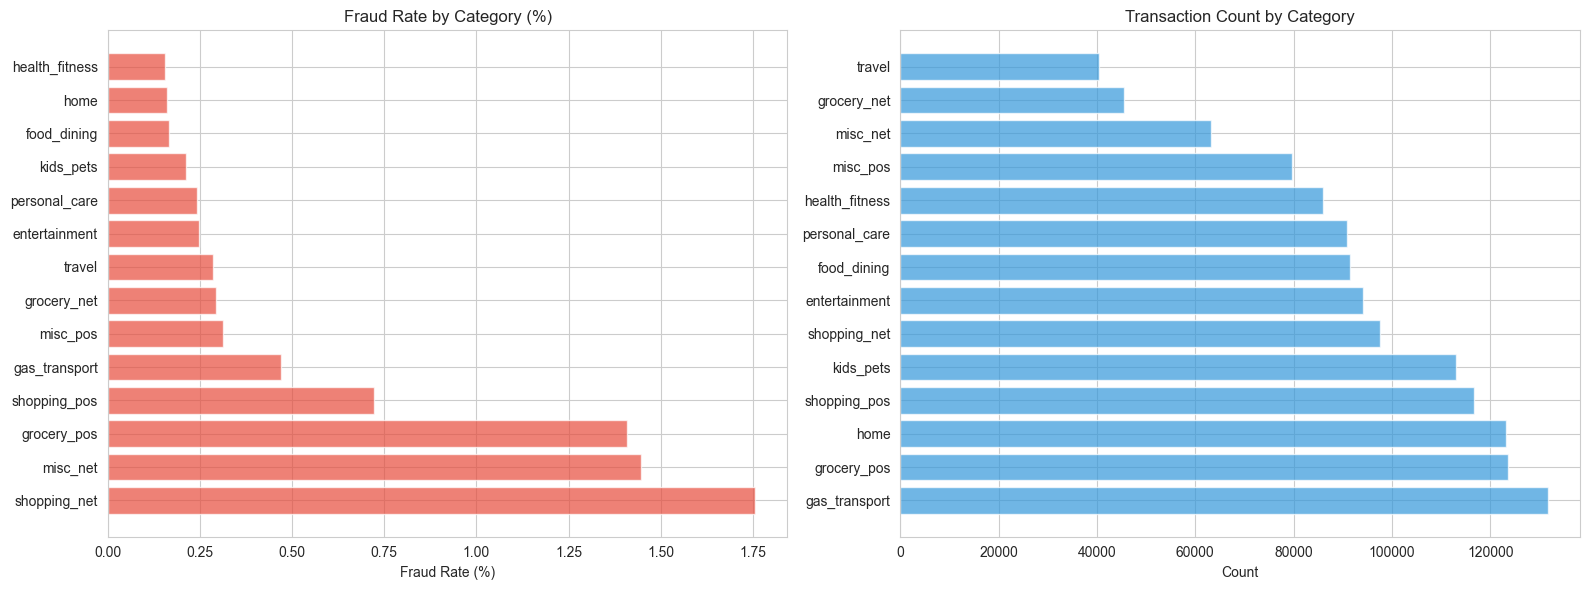


Fraud rate by category:
                 count  mean
category                    
shopping_net     97543  1.76
misc_net         63287  1.45
grocery_pos     123638  1.41
shopping_pos    116672  0.72
gas_transport   131659  0.47
misc_pos         79655  0.31
grocery_net      45452  0.29
travel           40507  0.29
entertainment    94014  0.25
personal_care    90758  0.24
kids_pets       113035  0.21
food_dining      91461  0.17
home            123115  0.16
health_fitness   85879  0.15


In [11]:
# Fraud rate by category
category_fraud = df.groupby('category')['is_fraud'].agg(['count', 'mean'])
category_fraud['mean'] = category_fraud['mean'] * 100
category_fraud = category_fraud.sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud rate by category
axes[0].barh(category_fraud.index, category_fraud['mean'], color='#e74c3c', alpha=0.7)
axes[0].set_title('Fraud Rate by Category (%)')
axes[0].set_xlabel('Fraud Rate (%)')

# Transaction count by category
category_counts = df['category'].value_counts()
axes[1].barh(category_counts.index, category_counts.values, color='#3498db', alpha=0.7)
axes[1].set_title('Transaction Count by Category')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print('\nFraud rate by category:')
print(category_fraud.round(2))

Fraud rate by gender:
         count  mean
gender              
F       709863  0.53
M       586812  0.64


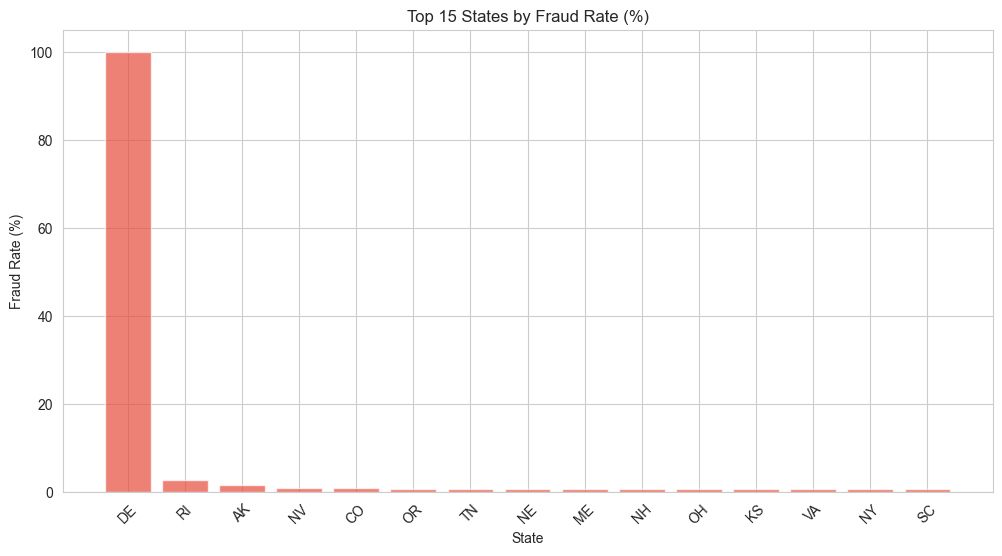

In [12]:
# Fraud rate by gender
gender_fraud = df.groupby('gender')['is_fraud'].agg(['count', 'mean'])
gender_fraud['mean'] = gender_fraud['mean'] * 100
print('Fraud rate by gender:')
print(gender_fraud.round(2))

# Fraud rate by state (top 15)
state_fraud = df.groupby('state')['is_fraud'].agg(['count', 'mean'])
state_fraud['mean'] = state_fraud['mean'] * 100
state_fraud = state_fraud.sort_values('mean', ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.bar(state_fraud.index, state_fraud['mean'], color='#e74c3c', alpha=0.7)
plt.title('Top 15 States by Fraud Rate (%)')
plt.xlabel('State')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45)
plt.show()

## 7. Geographic Analysis

Merchant distance statistics by class:
              count   mean    std   min    25%    50%    75%     max
is_fraud                                                            
0         1289169.0  76.11  29.12  0.02  55.33  78.23  98.50  152.12
1            7506.0  76.27  28.75  0.74  55.63  77.93  98.39  144.52


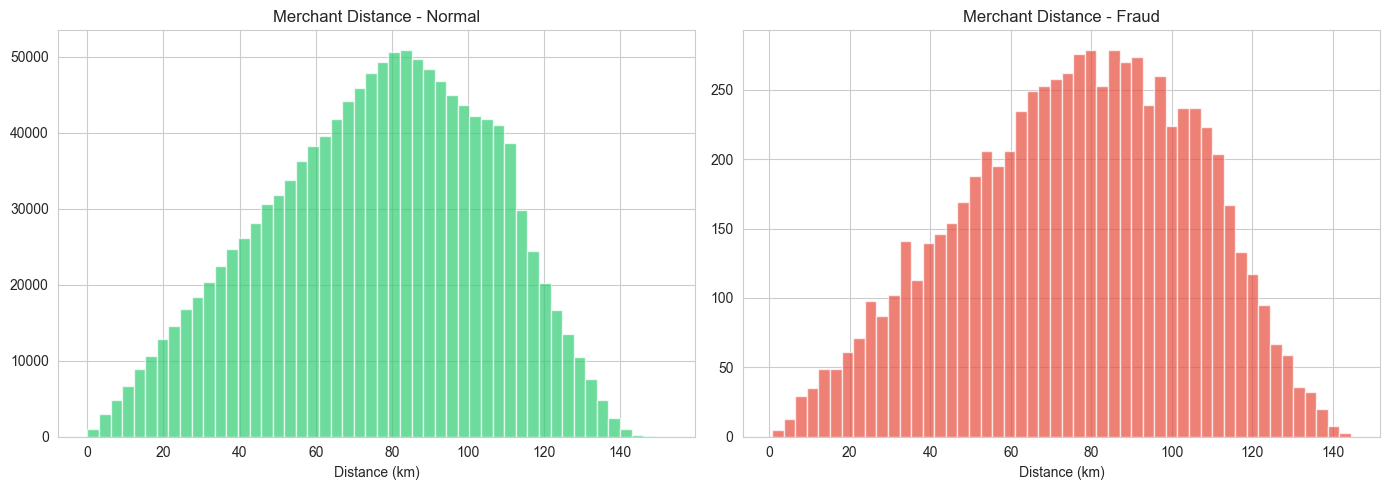

In [13]:
# Compute merchant distance using VECTORIZED haversine (fast, no row-by-row apply)
R = 6371.0  # Earth radius in km

lat1 = np.radians(df['lat'].values)
lon1 = np.radians(df['long'].values)
lat2 = np.radians(df['merch_lat'].values)
lon2 = np.radians(df['merch_long'].values)

dlat = lat2 - lat1
dlon = lon2 - lon1
a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
df['merchant_distance'] = 2 * R * np.arcsin(np.sqrt(np.minimum(1.0, a)))

print('Merchant distance statistics by class:')
print(df.groupby('is_fraud')['merchant_distance'].describe().round(2))

# Distance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, cls in enumerate([0, 1]):
    data = df[df['is_fraud'] == cls]['merchant_distance']
    axes[i].hist(data, bins=50, alpha=0.7, color=colors[i])
    axes[i].set_title(f'Merchant Distance - {"Normal" if cls == 0 else "Fraud"}')
    axes[i].set_xlabel('Distance (km)')

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

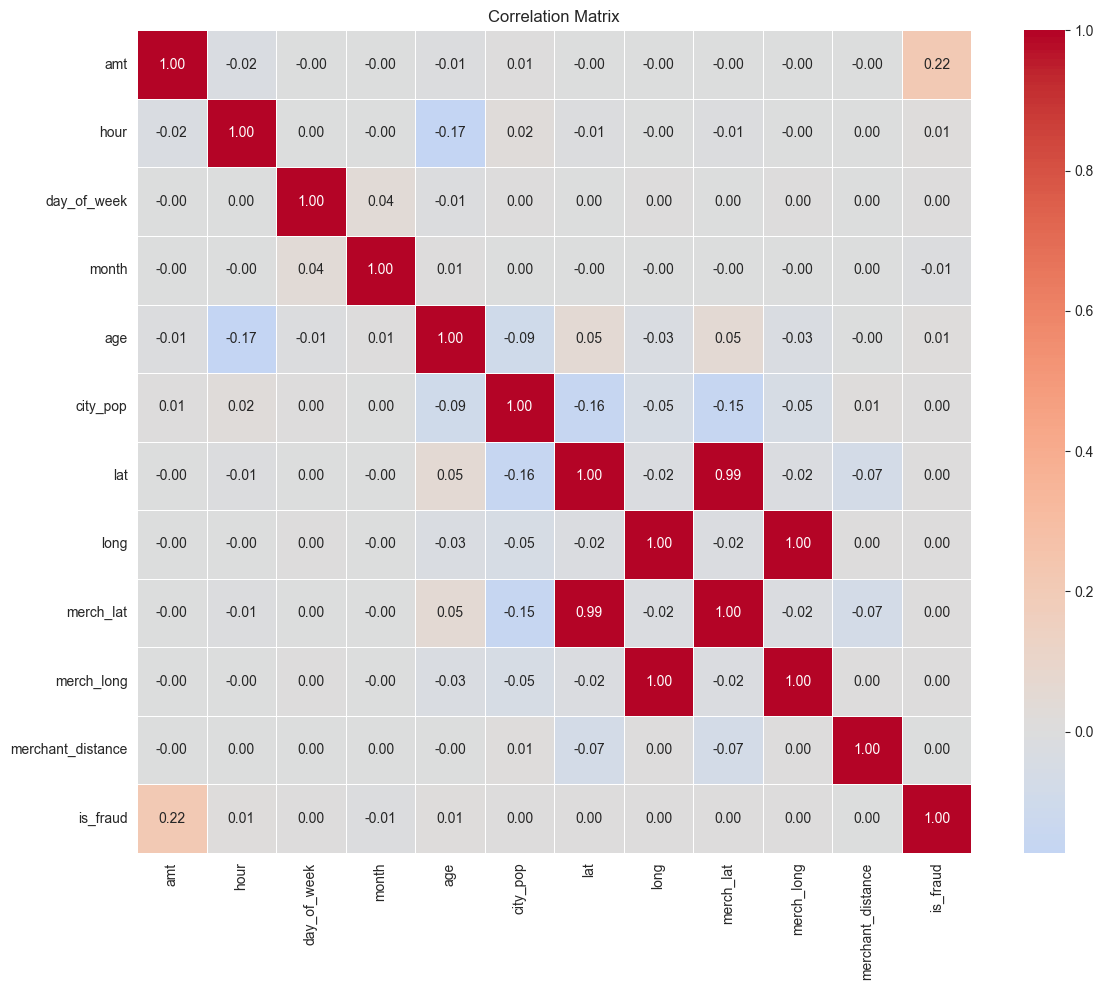

In [14]:
# Select numeric columns for correlation
numeric_cols = ['amt', 'hour', 'day_of_week', 'month', 'age', 'city_pop',
                'lat', 'long', 'merch_lat', 'merch_long', 'merchant_distance', 'is_fraud']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [15]:
# Correlation with target
target_corr = corr['is_fraud'].sort_values(ascending=False)
print('Correlation with is_fraud:')
print(target_corr)

Correlation with is_fraud:
is_fraud             1.000000
amt                  0.219404
hour                 0.013799
age                  0.012270
city_pop             0.002136
lat                  0.001894
merch_lat            0.001741
day_of_week          0.001739
merch_long           0.001721
long                 0.001721
merchant_distance    0.000403
month               -0.012409
Name: is_fraud, dtype: float64


## 9. High-Cardinality Columns

In [16]:
# Check cardinality of categorical columns
cat_cols = ['merchant', 'category', 'gender', 'state', 'job', 'city']
print('Cardinality of categorical columns:')
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} unique values')

# Top merchants
print('\nTop 10 merchants by transaction count:')
print(df['merchant'].value_counts().head(10))

# Top jobs
print('\nTop 10 jobs:')
print(df['job'].value_counts().head(10))

Cardinality of categorical columns:
  merchant: 693 unique values
  category: 14 unique values
  gender: 2 unique values
  state: 51 unique values
  job: 494 unique values


  city: 894 unique values

Top 10 merchants by transaction count:
merchant
fraud_Kilback LLC                   4403
fraud_Cormier LLC                   3649
fraud_Schumm PLC                    3634
fraud_Kuhn LLC                      3510
fraud_Boyer PLC                     3493
fraud_Dickinson Ltd                 3434
fraud_Cummerata-Jones               2736
fraud_Kutch LLC                     2734
fraud_Olson, Becker and Koch        2723
fraud_Stroman, Hudson and Erdman    2721
Name: count, dtype: int64

Top 10 jobs:
job
Film/video editor             9779
Exhibition designer           9199
Naval architect               8684
Surveyor, land/geomatics      8680
Materials engineer            8270
Designer, ceramics/pottery    8225
Systems developer             7700
IT trainer                    7679
Financial adviser             7659
Environmental consultant      7547
Name: count, dtype: int64


## 10. Key Insights Summary

Based on the EDA, here are the key findings:

1. **Extreme class imbalance**: Only 0.58% of transactions are fraudulent (7,506 out of 1,296,675)
2. **Amount patterns**: Fraudulent transactions tend to have different amount distributions than normal ones
3. **Temporal patterns**: Fraud rates vary by hour of day and day of week
4. **Category matters**: Certain merchant categories (e.g., misc_net, grocery_pos) have higher fraud rates
5. **Geographic signals**: Merchant distance from cardholder location may be a fraud indicator
6. **Age patterns**: Customer age distribution differs between fraud and normal transactions
7. **No missing values**: Dataset is clean with no missing data
8. **High-cardinality columns**: `merchant` (373), `job` (373), `city` (many) need special encoding

These insights will guide the feature engineering and cleaning pipeline in `cleaning.ipynb`.

## 11. Before vs After Cleaning Comparison

This section compares the raw dataset (`fraudTrain.csv`) with the cleaned, training-ready dataset (`cleaned_creditcard.csv`) to visualize the impact of the cleaning pipeline.

In [17]:
# Load both datasets
df_raw = pd.read_csv('dataset/fraudTrain.csv')
df_clean = pd.read_csv('dataset/cleaned_creditcard.csv')

print(f'Raw dataset: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
print(f'Cleaned dataset: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns')
print(f'\nRaw class distribution:')
print(df_raw['is_fraud'].value_counts().to_string())
print(f'\nCleaned class distribution:')
print(df_clean['is_fraud'].value_counts().to_string())

Raw dataset: 1,296,675 rows, 23 columns
Cleaned dataset: 402,865 rows, 18 columns

Raw class distribution:
is_fraud
0    1289169
1       7506

Cleaned class distribution:
is_fraud
0    322292
1     80573


### 11.1 Class Distribution Comparison

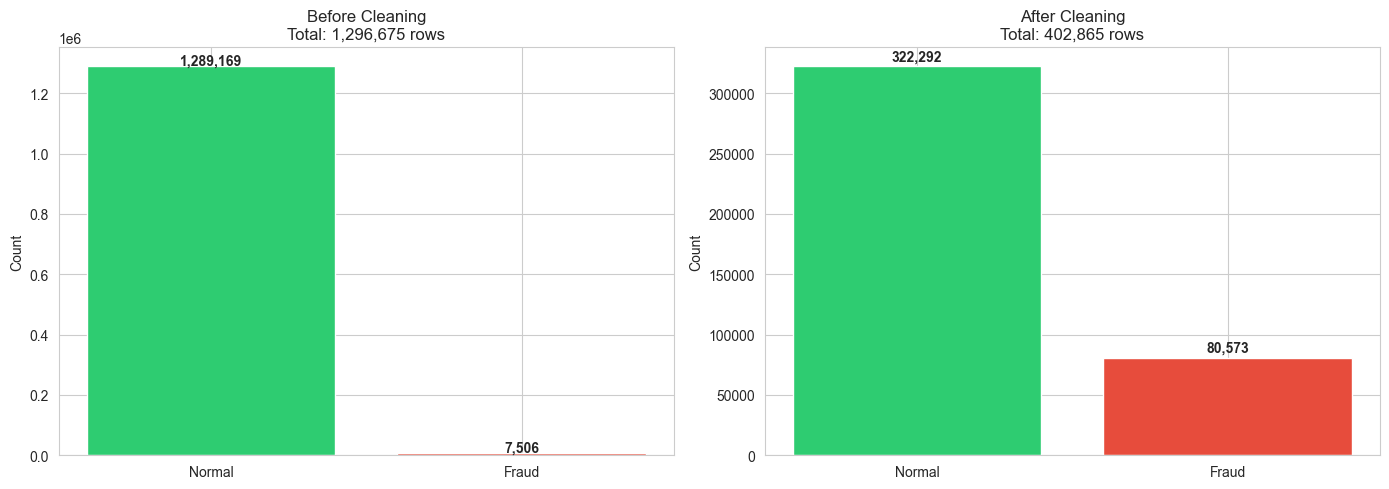

In [18]:
# Class distribution before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
raw_counts = df_raw['is_fraud'].value_counts()
axes[0].bar(['Normal', 'Fraud'], raw_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title(f'Before Cleaning\nTotal: {len(df_raw):,} rows')
axes[0].set_ylabel('Count')
for i, v in enumerate(raw_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

# After
clean_counts = df_clean['is_fraud'].value_counts()
axes[1].bar(['Normal', 'Fraud'], clean_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title(f'After Cleaning\nTotal: {len(df_clean):,} rows')
axes[1].set_ylabel('Count')
for i, v in enumerate(clean_counts.values):
    axes[1].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

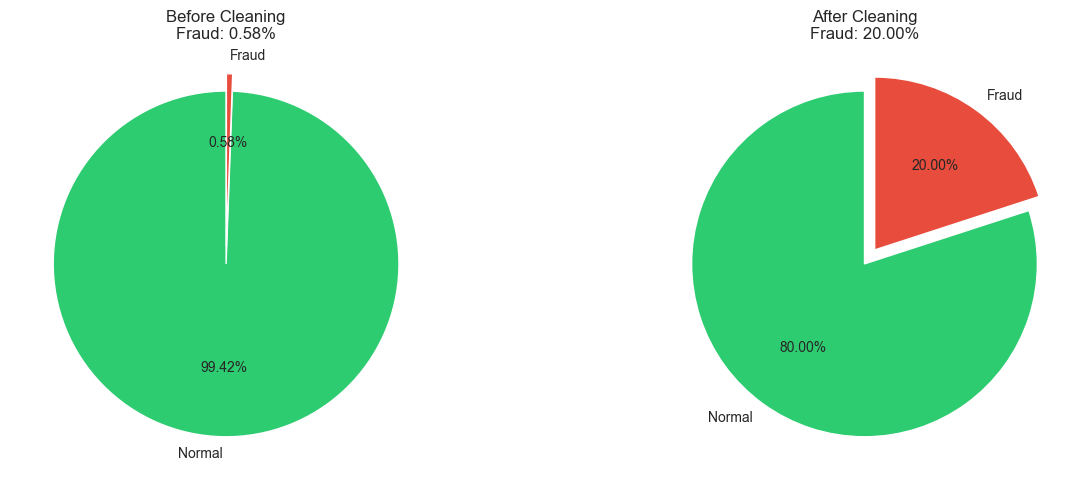

In [19]:
# Class ratio comparison (pie charts)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
raw_fraud_pct = df_raw['is_fraud'].mean() * 100
axes[0].pie([100 - raw_fraud_pct, raw_fraud_pct], labels=['Normal', 'Fraud'],
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
axes[0].set_title(f'Before Cleaning\nFraud: {raw_fraud_pct:.2f}%')

# After
clean_fraud_pct = df_clean['is_fraud'].mean() * 100
axes[1].pie([100 - clean_fraud_pct, clean_fraud_pct], labels=['Normal', 'Fraud'],
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
axes[1].set_title(f'After Cleaning\nFraud: {clean_fraud_pct:.2f}%')

plt.tight_layout()
plt.show()

### 11.2 Dataset Size Comparison

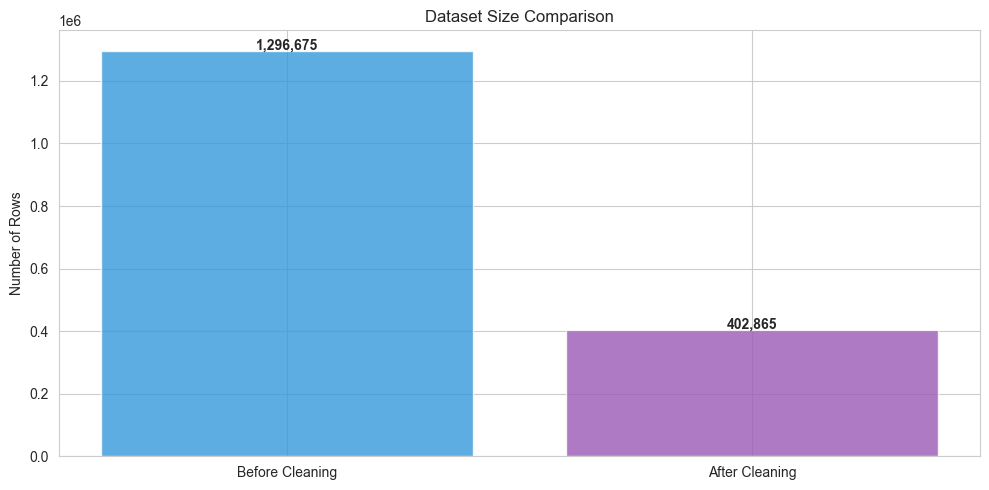

In [20]:
# Dataset size comparison
fig, ax = plt.subplots(figsize=(10, 5))
sizes = [len(df_raw), len(df_clean)]
labels = ['Before Cleaning', 'After Cleaning']
bars = ax.bar(labels, sizes, color=['#3498db', '#9b59b6'], alpha=0.8)
ax.set_title('Dataset Size Comparison')
ax.set_ylabel('Number of Rows')
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{size:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 11.3 Amount Distribution Comparison

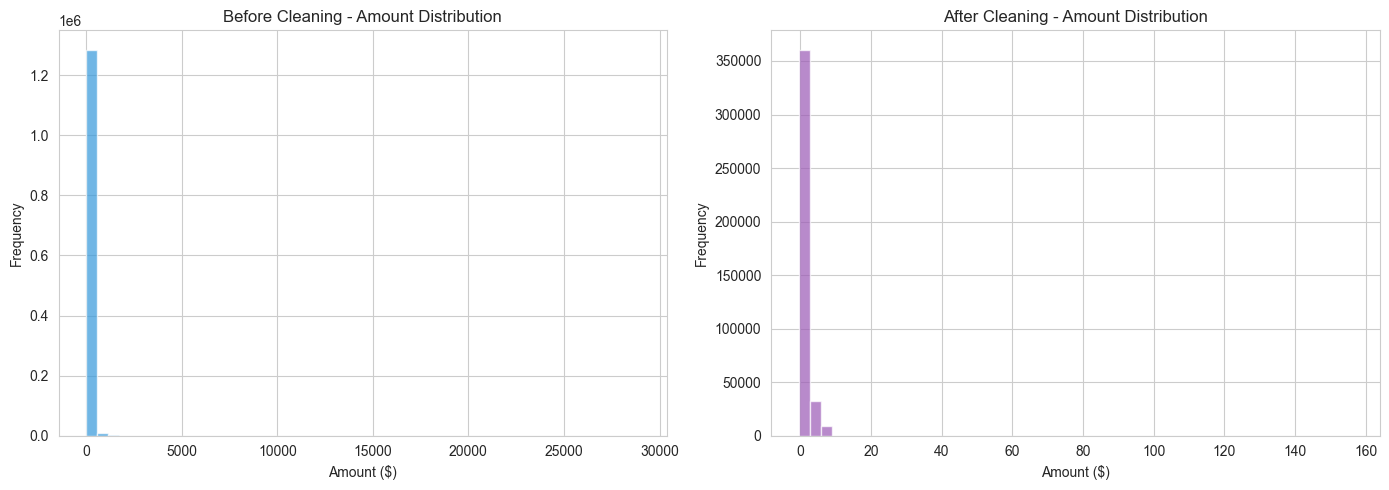

In [21]:
# Amount distribution before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].hist(df_raw['amt'], bins=50, alpha=0.7, color='#3498db')
axes[0].set_title('Before Cleaning - Amount Distribution')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')

# After
axes[1].hist(df_clean['amt'], bins=50, alpha=0.7, color='#9b59b6')
axes[1].set_title('After Cleaning - Amount Distribution')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

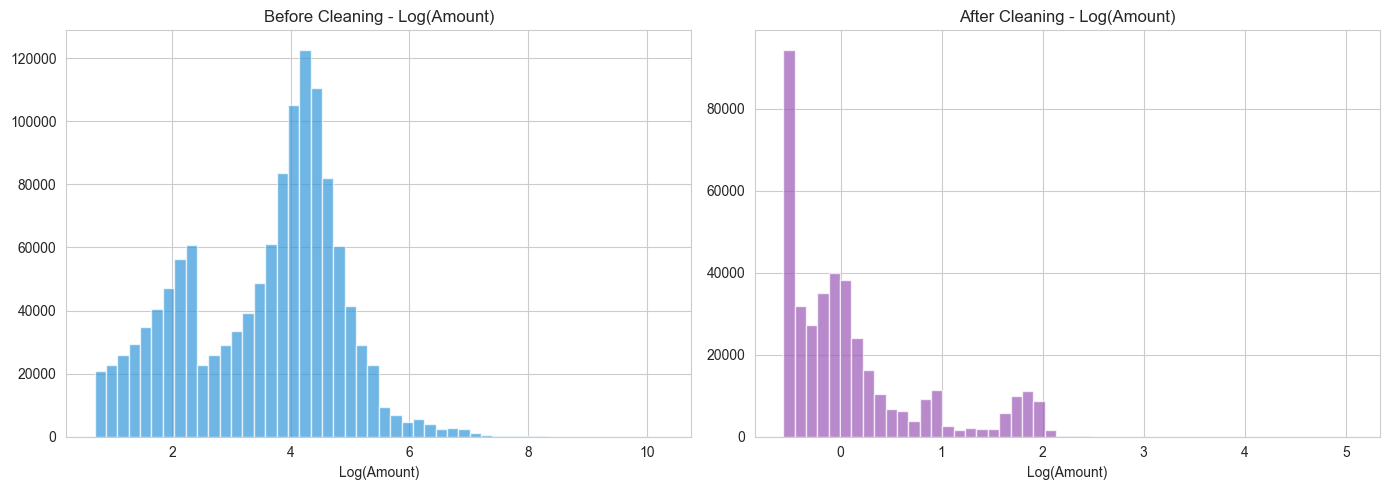

In [22]:
# Log-scale amount comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].hist(np.log1p(df_raw['amt']), bins=50, alpha=0.7, color='#3498db')
axes[0].set_title('Before Cleaning - Log(Amount)')
axes[0].set_xlabel('Log(Amount)')

# After
axes[1].hist(np.log1p(df_clean['amt']), bins=50, alpha=0.7, color='#9b59b6')
axes[1].set_title('After Cleaning - Log(Amount)')
axes[1].set_xlabel('Log(Amount)')

plt.tight_layout()
plt.show()

### 11.4 Feature Distribution Comparison

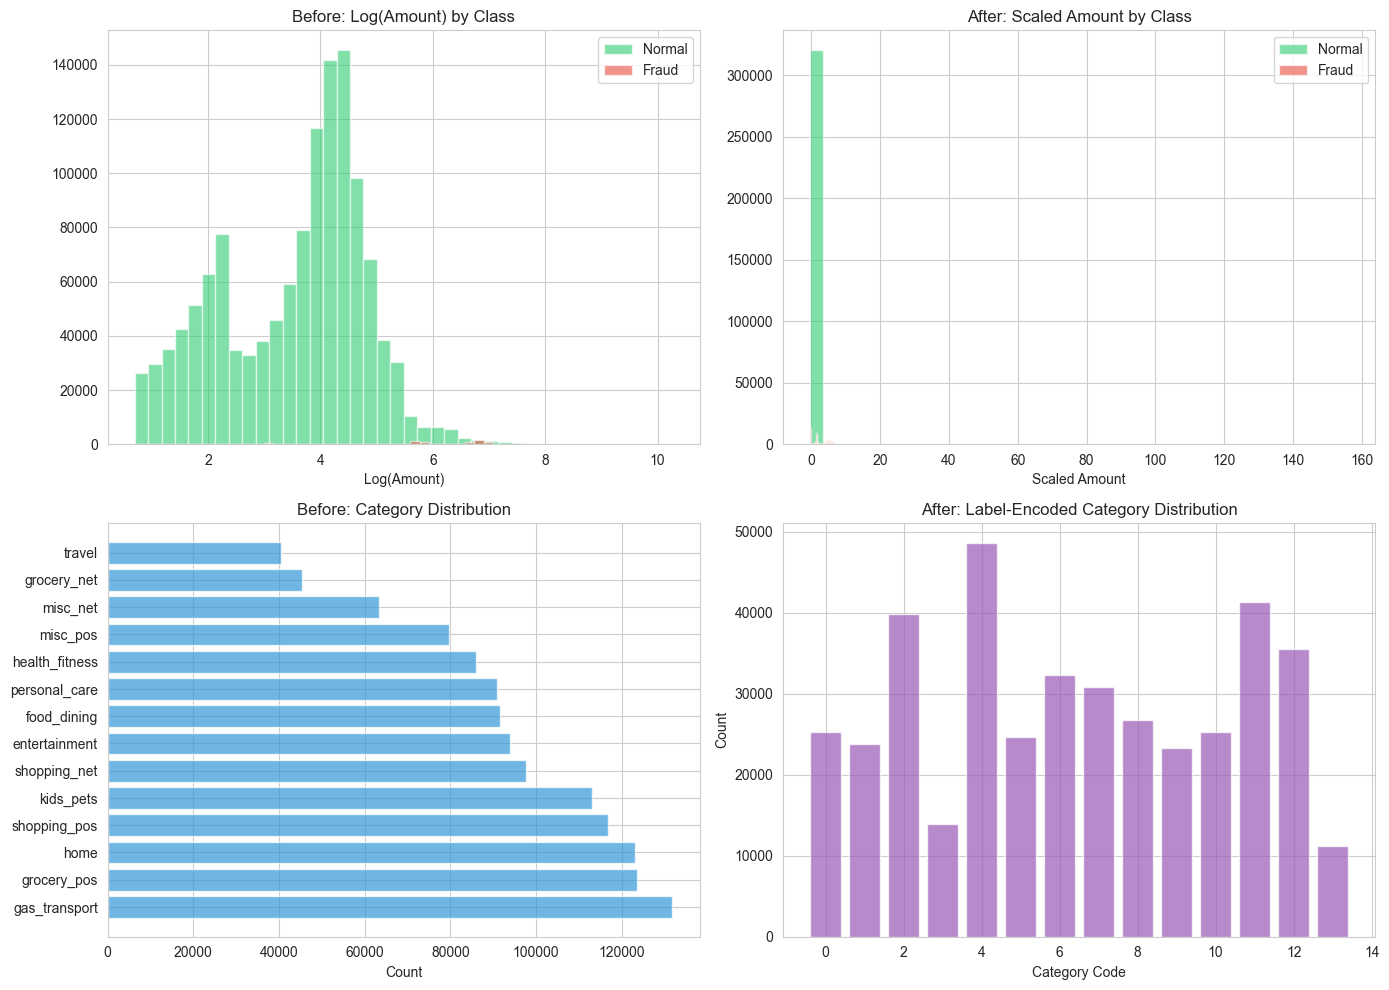

In [23]:
# Compare key feature distributions before vs after
# Note: cleaned dataset has scaled features, so we compare raw vs cleaned distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount by class - Before
for cls, color, label in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Fraud')]:
    data = df_raw[df_raw['is_fraud'] == cls]['amt']
    axes[0, 0].hist(np.log1p(data), bins=40, alpha=0.6, label=label, color=color)
axes[0, 0].set_title('Before: Log(Amount) by Class')
axes[0, 0].set_xlabel('Log(Amount)')
axes[0, 0].legend()

# Amount by class - After
for cls, color, label in [(0, '#2ecc71', 'Normal'), (1, '#e74c3c', 'Fraud')]:
    data = df_clean[df_clean['is_fraud'] == cls]['amt']
    axes[0, 1].hist(data, bins=40, alpha=0.6, label=label, color=color)
axes[0, 1].set_title('After: Scaled Amount by Class')
axes[0, 1].set_xlabel('Scaled Amount')
axes[0, 1].legend()

# Category distribution - Before
cat_counts_raw = df_raw['category'].value_counts()
axes[1, 0].barh(cat_counts_raw.index, cat_counts_raw.values, color='#3498db', alpha=0.7)
axes[1, 0].set_title('Before: Category Distribution')
axes[1, 0].set_xlabel('Count')

# Category distribution - After (label encoded)
cat_counts_clean = df_clean['category'].value_counts().sort_index()
axes[1, 1].bar(cat_counts_clean.index, cat_counts_clean.values, color='#9b59b6', alpha=0.7)
axes[1, 1].set_title('After: Label-Encoded Category Distribution')
axes[1, 1].set_xlabel('Category Code')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 11.5 Missing Values Comparison

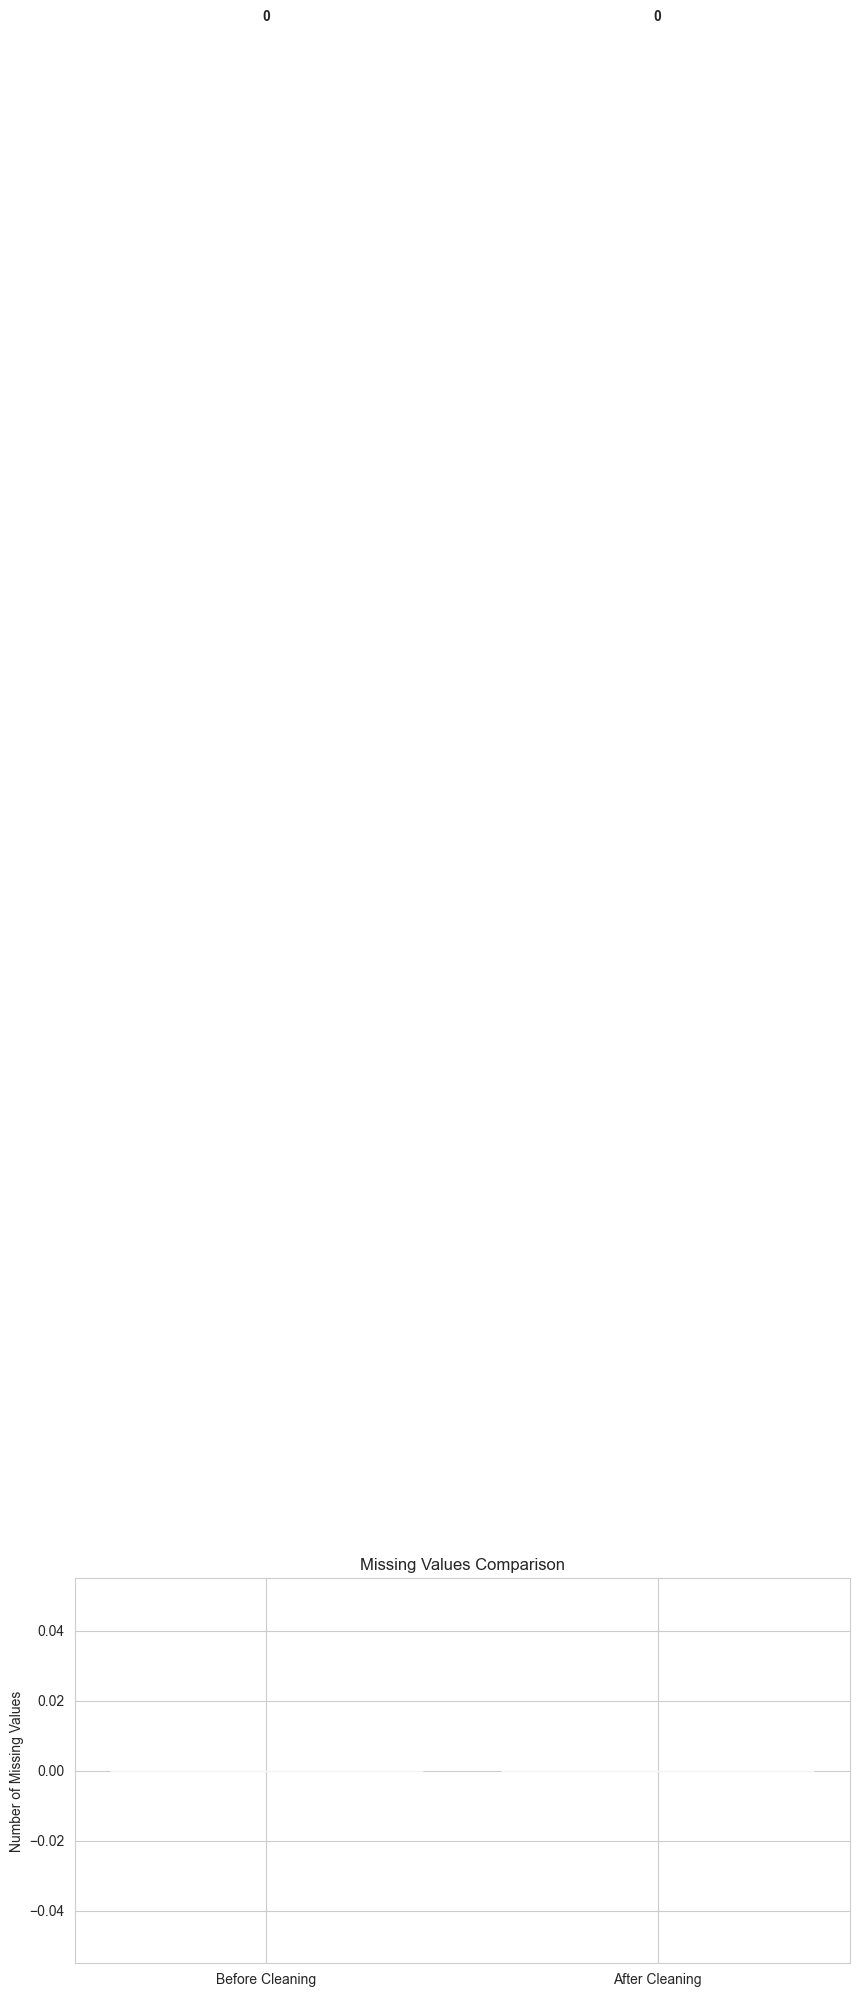

In [24]:
# Missing values comparison
fig, ax = plt.subplots(figsize=(10, 5))

raw_missing = df_raw.isnull().sum().sum()
clean_missing = df_clean.isnull().sum().sum()

bars = ax.bar(['Before Cleaning', 'After Cleaning'], [raw_missing, clean_missing],
              color=['#3498db', '#9b59b6'], alpha=0.8)
ax.set_title('Missing Values Comparison')
ax.set_ylabel('Number of Missing Values')
for bar, val in zip(bars, [raw_missing, clean_missing]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 11.6 Cleaning Pipeline Summary

| Metric | Before | After |
|---|---|---|
| **Total rows** | 1,296,675 | 402,865 |
| **Normal transactions** | 1,289,169 | 322,292 |
| **Fraud transactions** | 7,506 | 80,573 |
| **Fraud ratio** | 0.58% | 20.00% |
| **Missing values** | 0 | 0 |
| **Features** | 23 | 18 |

**Key transformations applied:**
1. Dropped 8 identifier columns (Unnamed: 0, trans_num, cc_num, first, last, street, city, zip)
2. Feature engineering: hour, day_of_week, month, age, merchant_distance
3. Label encoding: category, state; Binary: gender; Frequency: job, merchant
4. StandardScaler on all numeric features
5. Downsampled 75% of normal transactions
6. SMOTE applied to achieve 1:4 fraud:normal ratio